In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/cleaned/os_model_data.csv")

x_data = df["x"].values
y_data = df["y"].values

x0 = x_data[0]
y0 = y_data[0]

t = np.arange(len(x_data))

In [4]:
split = 50

x1 = x_data[:split]
y1 = y_data[:split]

x2 = x_data[split:]
y2 = y_data[split:]

In [5]:
t1 = np.arange(len(x1))
t2 = np.arange(len(x2))

In [6]:
x01 = x1[0]
y01 = y1[0]

x02 = x2[0]
y02 = y2[0]

In [7]:
def model(z, t, r1, r2, K, alpha, beta):

    x, y = z

    dx = r1*x*(1-(x+y)/K) - alpha*x*y
    dy = r2*y*(1-(x+y)/K) - beta*x*y

    return [dx, dy]

In [8]:
def simulate1(params):

    r1, r2, K, alpha, beta = params

    z0 = [x01, y01]

    sol = odeint(
        model,
        z0,
        t1,
        args=(r1, r2, K, alpha, beta)
    )

    return sol[:,0], sol[:,1]

In [9]:
def loss1(params):

    xm, ym = simulate1(params)

    return np.sum((xm-x1)**2 + (ym-y1)**2)

In [10]:
initial = [0.1,0.02,1,0.05,0.05]

bounds = [(0,1),(0,1),(0.5,2),(0,1),(0,1)]

res1 = minimize(loss1, initial, bounds=bounds)

p1 = res1.x
p1

array([0.08181321, 0.        , 0.96997045, 0.        , 0.01644414])

In [17]:
r1, r2, K, alpha, beta = p2

print("Phase 2")
print("r1 =", r1)
print("beta =", beta)

if r1 > 0 and beta > 0:
    print("x monopoly stable")
else:
    print("monopoly not stable")

Phase 2
r1 = 0.03424297616845408
beta = 0.0
monopoly not stable


In [11]:
def simulate2(params):

    r1, r2, K, alpha, beta = params

    z0 = [x02, y02]

    sol = odeint(
        model,
        z0,
        t2,
        args=(r1, r2, K, alpha, beta)
    )

    return sol[:,0], sol[:,1]

In [12]:
def loss2(params):

    xm, ym = simulate2(params)

    return np.sum((xm-x2)**2 + (ym-y2)**2)

In [13]:
res2 = minimize(loss2, initial, bounds=bounds)

p2 = res2.x
p2

array([0.03424298, 0.139449  , 1.00972422, 0.00410094, 0.        ])

In [14]:
r1, r2, K, alpha, beta = p1

print("Phase 1")
print("r1 =", r1)
print("beta =", beta)

if r1 > 0 and beta > 0:
    print("x monopoly stable")
else:
    print("monopoly not stable")

Phase 1
r1 = 0.08181320905484209
beta = 0.016444139639843872
x monopoly stable


In [15]:
xm1, ym1 = simulate1(p1)
xm2, ym2 = simulate2(p2)

x_model = np.concatenate([xm1, xm2])
y_model = np.concatenate([ym1, ym2])

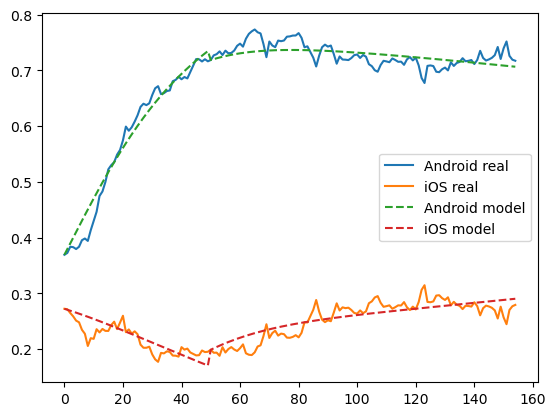

In [16]:
plt.plot(x_data,label="Android real")
plt.plot(y_data,label="iOS real")

plt.plot(x_model,"--",label="Android model")
plt.plot(y_model,"--",label="iOS model")

plt.legend()
plt.show()